In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score

In [106]:
csvpath = '../ickd__gpt-3-5-turbo__sst2___n1000000_s0_e67349.csv'
df = pd.read_csv(csvpath)
df.head()

,index,sentence,label,positive_prob,negative_prob
0,0,hide new secretions from the parental units,0,0.001140,0.998400
1,1,"contains no wit , only labored gags",0,-1.000000,0.994419
2,2,that loves its characters and communicates som...,1,0.999983,0.000013
3,3,remains utterly satisfied to remain the same t...,0,0.016052,0.982627
4,4,on the worst revenge-of-the-nerds clichés the ...,0,0.000070,0.999721


In [107]:
df['soft_label']  = np.where(df['positive_prob'] > df['negative_prob'], 1, 0)
df.head()

,index,sentence,label,positive_prob,negative_prob,soft_label
0,0,hide new secretions from the parental units,0,0.001140,0.998400,0
1,1,"contains no wit , only labored gags",0,-1.000000,0.994419,0
2,2,that loves its characters and communicates som...,1,0.999983,0.000013,1
3,3,remains utterly satisfied to remain the same t...,0,0.016052,0.982627,0
4,4,on the worst revenge-of-the-nerds clichés the ...,0,0.000070,0.999721,0


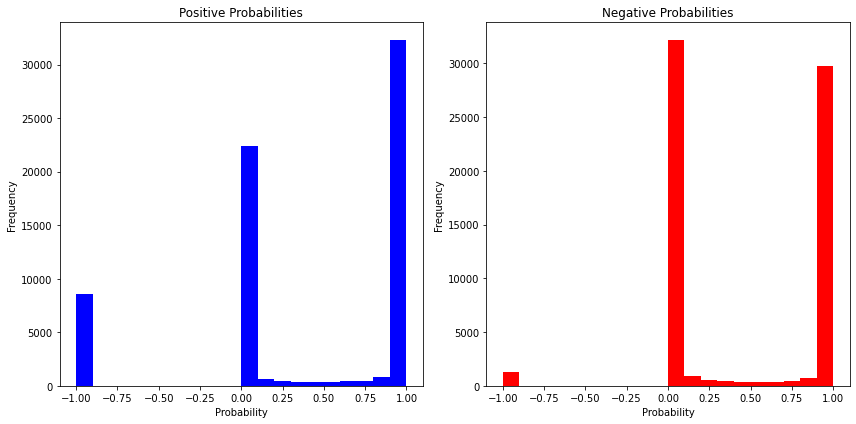

In [27]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['positive_prob'], bins=20, color='blue')
plt.title('Positive Probabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['negative_prob'], bins=20, color='red')
plt.title('Negative Probabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

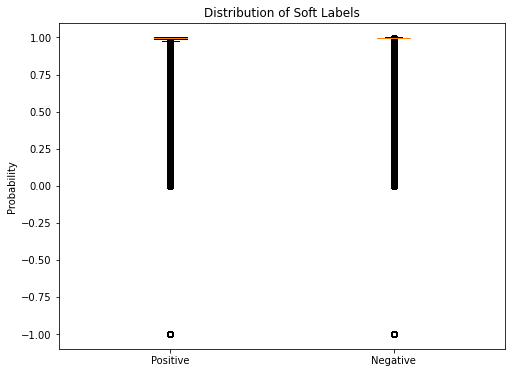

In [33]:
plt.figure(figsize=(8, 6))
plt.boxplot([df[df['label'] == 1]['positive_prob'], df[df['label'] == 0]['negative_prob']],
            labels=['Positive', 'Negative'])
plt.ylabel('Probability')
plt.title('Distribution of Soft Labels')
plt.show()

In [108]:
# % where positive_prob == 1 among positive labels
print("Number of positive_prob = 1: ", len(df[df['positive_prob'] == 1]))
print("Number of positive_prob = 0: ", len(df[df['positive_prob'] == 0]))
print("Number of positive_prob = -1: ", len(df[df['positive_prob'] == -1]))
print("Number of negative_prob = 1: ", len(df[df['negative_prob'] == 1]))
print("Number of negative_prob = 0: ", len(df[df['negative_prob'] == 0]))
print("Number of negative_prob = -1: ", len(df[df['negative_prob'] == -1]))


Number of positive_prob = 1:  0
Number of positive_prob = 0:  0
Number of positive_prob = -1:  8579
Number of negative_prob = 1:  0
Number of negative_prob = 0:  0
Number of negative_prob = -1:  1284


In [109]:
precision = precision_score(df['label'], df['soft_label'], average='binary')
recall = recall_score(df['label'], df['soft_label'], average='binary')
accuracy = accuracy_score(df['label'], df['soft_label'])

print(f'Precision: {precision}, Recall: {recall}, Accuracy: {accuracy}')

Precision: 0.9728055077452668, Recall: 0.9026591072426735, Accuracy: 0.9316248199676312


In [111]:
unsure_pos = df[(df['positive_prob'] >= 0.25) & (df['positive_prob'] <= 0.75)]
print(f"Positive probabilities between 0.25 and 0.75: {len(unsure_pos)} ({100*len(unsure_pos)/len(df)}%)")

unsure_pos_precision = precision_score(unsure_pos['label'], unsure_pos['soft_label'], average='binary')
unsure_pos_recall = recall_score(unsure_pos['label'], unsure_pos['soft_label'], average='binary')
unsure_pos_accuracy = accuracy_score(unsure_pos['label'], unsure_pos['soft_label'])

print(f'Precision: {unsure_pos_precision}, Recall: {unsure_pos_recall}, Accuracy: {unsure_pos_accuracy}')

Positive probabilities between 0.25 and 0.75: 2007 (2.979999703039392%)
Precision: 0.7991525423728814, Recall: 0.6220316622691293, Accuracy: 0.5964125560538116


In [112]:
np.allclose(unsure_pos['positive_prob'] + unsure_pos['negative_prob'], 1)

False

In [113]:
unsure_neg = df[(df['negative_prob'] >= 0.25) & (df['negative_prob'] <= 0.75)]
print(f"Negative probabilities between 0.25 and 0.75: {len(unsure_neg)} ({100*len(unsure_neg)/len(df)}%)")

unsure_neg_precision = precision_score(unsure_neg['label'], unsure_neg['soft_label'], pos_label=0, average='binary')
unsure_neg_recall = recall_score(unsure_neg['label'], unsure_neg['soft_label'], pos_label=0, average='binary')
unsure_neg_accuracy = accuracy_score(unsure_neg['label'], unsure_neg['soft_label'])

print(f'Precision: {unsure_neg_precision}, Recall: {unsure_neg_recall}, Accuracy: {unsure_neg_accuracy}')

Negative probabilities between 0.25 and 0.75: 2024 (3.0052413547342947%)
Precision: 0.3292999135695765, Recall: 0.6591695501730104, Accuracy: 0.5192687747035574


In [114]:
certain_pos = df[(df['positive_prob'] >= 0.9)]
print(f"Positive probabilities above 0.9: {len(certain_pos)} ({100*len(certain_pos)/len(df)}%)")
certain_pos_precision = precision_score(certain_pos['label'], certain_pos['soft_label'], average='binary')
certain_pos_recall = recall_score(certain_pos['label'], certain_pos['soft_label'], average='binary')
certain_pos_accuracy = accuracy_score(certain_pos['label'], certain_pos['soft_label'])

print(f'Precision: {certain_pos_precision}, Recall: {certain_pos_recall}, Accuracy: {certain_pos_accuracy}')

certain_neg = df[(df['negative_prob'] >= 0.9)]
print(f"Negative probabilities above 0.9: {len(certain_neg)} ({100*len(certain_neg)/len(df)}%)")

certain_neg_precision = precision_score(certain_neg['label'], certain_neg['soft_label'], pos_label=0, average='binary')
certain_neg_recall = recall_score(certain_neg['label'], certain_neg['soft_label'], pos_label=0, average='binary')
certain_neg_accuracy = accuracy_score(certain_neg['label'], certain_neg['soft_label'])

print(f'Precision: {certain_neg_precision}, Recall: {certain_neg_recall}, Accuracy: {certain_neg_accuracy}')

Positive probabilities above 0.9: 32322 (47.99180388721436%)
Precision: 0.9837881319225296, Recall: 1.0, Accuracy: 0.9837881319225296
Negative probabilities above 0.9: 29746 (44.16695125391617%)
Precision: 0.9376050561420023, Recall: 1.0, Accuracy: 0.9376050561420023


In [115]:
certain_neg[certain_neg['label'] != certain_neg['soft_label']]

,index,sentence,label,positive_prob,negative_prob,soft_label
94,94,"it does n't follow the stale , standard , conn...",1,0.007370,0.992504,0
103,103,hate to tear your eyes away from the images lo...,1,0.096338,0.903568,0
168,168,"eats , meddles , argues , laughs , kibbitzes a...",1,0.067073,0.900290,0
172,172,"the picture runs a mere 84 minutes , but it 's...",1,0.002112,0.997729,0
266,266,slick and manufactured to claim street credibi...,1,0.076696,0.922951,0
...,...,...,...,...,...,...
67197,67197,that old adage about women being unknowable,1,0.001392,0.997124,0
67232,67232,a brilliant college student -- where 's pauly ...,1,0.001594,0.998332,0
67241,67241,"i liked about schmidt a lot , but i have a fee...",1,0.016477,0.983326,0
67291,67291,junior-high,1,0.001587,0.995373,0


In [116]:
def expected_calibration_error(samples, true_labels, M=10):
    # uniform binning approach with M number of bins
    bin_boundaries = np.linspace(0, 1, M + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    # get max probability per sample i
    confidences = np.max(samples, axis=1)
    # print(confidences)
    # get predictions from confidences (positional in this case)
    predicted_label = np.argmax(samples, axis=1)
    predicted_label = np.where(predicted_label == 1, 0, 1)
    # print(predicted_label)
    # print(true_labels)

    # get a boolean list of correct/false predictions
    accuracies = predicted_label == true_labels
    # print(accuracies)

    ece = np.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # determine if sample is in bin m (between bin lower & upper)
        in_bin = np.logical_and(confidences > bin_lower.item(), confidences <= bin_upper.item())
        # can calculate the empirical probability of a sample falling into bin m: (|Bm|/n)
        prob_in_bin = in_bin.mean()

        if prob_in_bin.item() > 0:
            # get the accuracy of bin m: acc(Bm)
            accuracy_in_bin = accuracies[in_bin].mean()
            # get the average confidence of bin m: conf(Bm)
            avg_confidence_in_bin = confidences[in_bin].mean()
            # calculate |acc(Bm) - conf(Bm)| * (|Bm|/n) for bin m and add to the total ECE
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prob_in_bin
    return ece


In [118]:
# df without any -1 probabilities in negative_prob and positive_prob
df_cleaned = df[(df['negative_prob'] != -1) & (df['positive_prob'] != -1)]

assert np.all(df_cleaned['negative_prob'].between(0, 1))
assert np.all(df_cleaned['positive_prob'].between(0, 1))

In [119]:
samples = np.column_stack((df_cleaned['positive_prob'], df_cleaned['negative_prob']))
true_labels = df_cleaned['label'].values

M = 10  # Number of bins
ece = expected_calibration_error(samples, true_labels, M=M)
print(f'Expected Calibration Error: {ece[0]}')

Expected Calibration Error: 0.046139956882756045


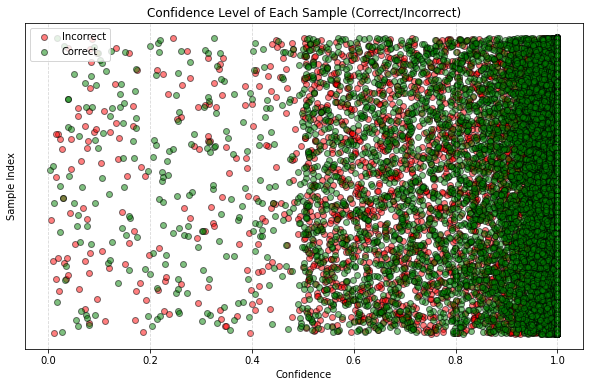

In [122]:
def plot_sample_confidences(samples, true_labels):
    # Estimate model confidences and predicted classes
    confidences = np.max(samples, axis=1)
    predicted_label = np.argmax(samples, axis=1)
    predicted_label = np.where(predicted_label == 1, 0, 1)

    # Actual results comparison
    correct_predictions = predicted_label == true_labels

    # Visual separation for clarity
    plot_offset = np.random.rand(*confidences.shape) * 0.1  # Add a small jitter

    # Scatter plot: correct in green, incorrect in red
    plt.figure(figsize=(10, 6))
    plt.scatter(confidences[~correct_predictions], plot_offset[~correct_predictions], 
                color='red', label='Incorrect', alpha=0.5, edgecolor='black')
    plt.scatter(confidences[correct_predictions], plot_offset[correct_predictions], 
                color='green', label='Correct', alpha=0.5, edgecolor='black')
    

    plt.xlabel('Confidence')
    plt.ylabel('Sample Index')
    plt.yticks([])  # Hide y-axis ticks, as they don't represent meaningful data
    plt.title('Confidence Level of Each Sample (Correct/Incorrect)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Assuming the `samples` are based on model's `positive_prob` and `negative_prob`
samples = np.column_stack((df_cleaned['positive_prob'], df_cleaned['negative_prob']) )
true_labels = df_cleaned['label'].values

plot_sample_confidences(samples, true_labels)


/Users/yooni/opt/anaconda3/envs/yooni/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


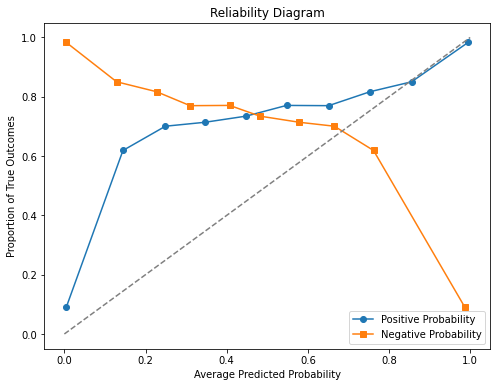

In [131]:
# Define the number of bins
num_bins = 10

# Create bins for predicted probability
bins = np.linspace(0, 1, num_bins + 1)

# Bin the predicted probabilities
df_cleaned['bin'] = pd.cut(df_cleaned['positive_prob'], bins=bins, labels=False, include_lowest=True)
pos_bin_data = df_cleaned.groupby('bin').agg({'positive_prob': 'mean', 'label': lambda x: np.mean(x==1)}).reset_index()
neg_bin_data = df_cleaned.groupby('bin').agg({'negative_prob': 'mean', 'label': lambda x: np.mean(x==0)}).reset_index()
# print(neg_bin_data)
# Plot the reliability diagram
plt.figure(figsize=(8, 6))
# Plot for positive probabilities
plt.plot(pos_bin_data['positive_prob'], pos_bin_data['label'], marker='o', label='Positive Probability')
# Plot for negative probabilities
plt.plot(neg_bin_data['negative_prob'], 1-neg_bin_data['label'], marker='s', label='Negative Probability')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line for reference
plt.xlabel('Average Predicted Probability')
plt.ylabel('Proportion of True Outcomes')
plt.title('Reliability Diagram')
plt.legend()
plt.show()
